# Chicago Crime Era Structural Analysis

**Author:** Erik Pak  
**Date:** 04/2026  
**Data:** Chicago Data Portal - Crime Incidents 2001–2025

---

## Research Question

> Did COVID-19 immediately reorganize the directional co-movement of crime types, but the reorganization of temporal rhythms occurred later in the post-COVID period?

---

## Era Definitions

| Era | Period | Months |
|---|---|---|
| Pre-COVID | Jan 2001 – Feb 2020 | 230 |
| COVID | Mar 2020 – Dec 2022 | 34 |
| Post-COVID | Jan 2023 – Dec 2025 | 36 |

**Era cutoff rationale:** The COVID era begins in March 2020, coinciding with the Illinois stay-at-home order (March 21, 2020) and the WHO pandemic declaration (March 11, 2020). The post-COVID era begins in January 2023, following the expiration of Illinois's disaster proclamation and the effective end of major federal pandemic-era policies in late 2022. These boundaries are administrative and policy-based; the underlying behavioral and enforcement shifts may not align exactly with these dates.

---

## Methodology

To examine temporal structure in crime patterns across the pre-COVID, COVID, and post-COVID periods, this study employs both correlation-based distance and Dynamic Time Warping (DTW), which capture complementary notions of similarity. Correlation distance quantifies the degree of co-movement in direction and proportional change between time series, implicitly assuming temporal alignment. As such, it is sensitive to synchronous behavior but may underestimate similarity when comparable dynamics occur with temporal offsets. In contrast, DTW provides a flexible, nonlinear alignment that finds the optimal correspondence between two series by allowing the time axis to stretch or compress locally, minimizing the cumulative distance along the best-fitting alignment path, thereby emphasizing overall shape and structural features even when events occur at different times. This makes DTW particularly well-suited for identifying temporal heterogeneity, including lagged responses, delayed peaks, and stretched or compressed patterns.

These distance measures serve as a basis for comparing relational structures across eras, with statistical inference drawn from distributional tests rather than direct causal attribution. Clustering results derived from correlation and DTW distances are jointly interpreted as a diagnostic framework: convergence between the two suggests stable structural relationships, whereas divergence indicates that apparent differences may be attributable to temporal misalignment rather than substantive changes in underlying dynamics. To further evaluate cluster validity, Z-gap and R-spike diagnostics are applied to assess separation and the presence of dominant regimes, providing additional evidence regarding the robustness of identified groupings without asserting definitive ground truth.

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import random
from importlib.metadata import version
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

# ── Reproducibility ──────────────────────────────────────────────────────────
# SEED is applied to all random processes throughout the pipeline.
SEED = 1776

# ── Path + custom modules ─────────────────────────────────────────────────────
sys.path.append('../Src/')
import crime_era_clustering as hc
import analyze_fill_stats as af
import era_plot as plot

# ── Library versions ──────────────────────────────────────────────────────────
versions = {
    "Python"  : sys.version.split()[0],
    "Pandas"  : pd.__version__,
    "NumPy"   : np.__version__,
    "Pyarrow" : pa.__version__,
    "Seaborn" : sns.__version__,
    "Matplot" : sys.modules['matplotlib'].__version__,
    "Scipy"   : sys.modules['scipy'].__version__,
}
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# ── Display settings ──────────────────────────────────────────────────────────
np.set_printoptions(suppress=True, precision=4, linewidth=100)
pd.set_option('display.max_rows', None)

   Library Version
0   Python  3.13.9
1   Pandas   2.3.3
2    NumPy   2.3.4
3  Pyarrow  22.0.0
4  Seaborn  0.13.2
5  Matplot  3.10.7
6    Scipy  1.16.3


## Data Import

Chicago crime incident data was loaded from a PyArrow Feather file. The dataset contains **8,469,443 records** across 34 columns, spanning January 2001 through December 2025, after further processing by the `ChicagoCrimeEraAnalysis.ipynb` notebook.

In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data_covid.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,...,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,year_week,year_month,Indexed
0,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,0324,...,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing,2001-04,200101,N
1,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,0624,...,Saturday,Q3,2003-Q3,Evening,Larceny – Theft,True,Gresham,2003-28,200307,I
2,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,True,False,1122,...,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison,2004-51,200412,N
3,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,2512,...,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central,2006-13,200603,I
4,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,True,False,2522,...,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central,2007-21,200705,N


In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469443 entries, 0 to 8469442
Data columns (total 34 columns):
 #   Column                Non-Null Count    Dtype                                                       
---  ------                --------------    -----                                                       
 0   case_number           8469443 non-null  string[pyarrow]                                             
 1   date                  8469443 non-null  timestamp[s][pyarrow]                                       
 2   block                 8469443 non-null  string[pyarrow]                                             
 3   iucr                  8469443 non-null  string[pyarrow]                                             
 4   primary_type          8469443 non-null  string[pyarrow]                                             
 5   description           8469443 non-null  string[pyarrow]                                             
 6   location_description  8454105 non-

In [4]:
df.era.unique()

<ArrowExtensionArray>
['pre_covid', 'post_covid', 'covid']
Length: 3, dtype: dictionary<values=string, indices=int8, ordered=0>[pyarrow]

In [5]:
# Separate by era
pre_df   = df[df.era == 'pre_covid']
covid_df = df[df.era == 'covid']
post_df  = df[df.era == 'post_covid']
# display shape
pre_df.shape, covid_df.shape, post_df.shape

((7092647, 34), (623871, 34), (752925, 34))

## Data Preparation

Each raw record represents a single crime incident. To enable era-level analysis, records are aggregated to monthly crime counts per crime type using `groupby(['year_month', 'fbi_code_desc']).size()`. This produces a long-format dataframe with one row per crime type per month, which is the foundation for all downstream analysis.

The three era dataframes are then separated, missing crime/month combinations are identified and filled with zero (true zeros - months with no recorded incidents), and a datetime `date` column is parsed from the integer `year_month` field.

In [6]:
# Aggregate to monthly crime counts per crime type
pre_df   = pre_df.groupby(['year_month', 'fbi_code_desc']).size().reset_index(name="crime_count")
covid_df = covid_df.groupby(['year_month', 'fbi_code_desc']).size().reset_index(name="crime_count")
post_df  = post_df.groupby(['year_month', 'fbi_code_desc']).size().reset_index(name="crime_count")

In [7]:
# Quick check on each era
print("::: Pre-COVID :::")
print(pre_df.shape)
print(pre_df['year_month'].min(), pre_df['year_month'].max())

print("\n::: COVID :::")
print(covid_df.shape)
print(covid_df['year_month'].min(), covid_df['year_month'].max())

print("\n::: Post-COVID :::")
print(post_df.shape)
print(post_df['year_month'].min(), post_df['year_month'].max())

::: Pre-COVID :::
(5788, 3)
200101 202002

::: COVID :::
(846, 3)
202003 202212

::: Post-COVID :::
(891, 3)
202301 202512


In [8]:
# Number of months per era: derive dynamically from feather file
era_months = (
    df.groupby('era')['year_month']
    .nunique()
    .to_dict()
)

# Build an era dict with DataFrame data
era_dict = {
    'pre_covid':  pre_df,
    'covid':      covid_df,
    'post_covid': post_df,
}

# Ground truth expectation
expected_era_months = {'pre_covid': 230, 'covid': 34, 'post_covid': 36}

# Era Completeness Analysis
af.run_era_integrity_report(era_dict, expected_era_months)

# New dictionary that bundles the data with its corresponding time index
era_data = {key: (data, era_months[key]) for key, data in era_dict.items()}

Era month counts verified: {'pre_covid': 230, 'covid': 34, 'post_covid': 36}

Era             | Expected   | Actual     | Missing
-------------------------------------------------------
pre_covid       | 5980       | 5788       | 192
 └── Missing counts by crime category:
fbi_code_desc
Involuntary Manslaughter / Reckless Homicide    187
Embezzlement                                      3
Gambling                                          2

covid           | 884        | 846        | 38
 └── Missing counts by crime category:
fbi_code_desc
Involuntary Manslaughter / Reckless Homicide    16
Gambling                                        13
Embezzlement                                     5
Prostitution                                     2
Stolen Property (Buy, Receive, Possess)          2

post_covid      | 936        | 891        | 45
 └── Missing counts by crime category:
fbi_code_desc
Involuntary Manslaughter / Reckless Homicide    27
Gambling                                        1

## Fill Missing with Zero

After identifying missing crime/month combinations in each era:

- **Involuntary Manslaughter** - missing 187/230 pre-COVID months. This crime is genuinely rare, so most months had zero incidents and simply were not recorded as a row.
- **Gambling, Embezzlement, Prostitution, Stolen Property** - sporadically missing for the same reason: rare months with zero counts.

These are **true zeros**, not missing data. The correct fix is to fill with 0, not drop these crimes - especially since Involuntary Manslaughter's rarity vs. spike pattern is exactly the kind of signal z-gap and r-spike are designed to catch.

In [9]:
# Rebuild era_data with prepared + filled dataframes
# ERA data -> preprocess -> fills missing month/crime combinations -> stores the cleaned version per era
era_data_filled = {}  # Create empty dictionary
for label, (raw_df, expected_months) in era_data.items(): # Loop through each era
    d = af.prepare_era_data(raw_df, label)                # Clean the data: helper function
    d = af.fill_missing(d)                                # Fill missing structure
    era_data_filled[label] = d                            # Store result
    print(f"{label}: {len(d)} rows after fill")

print("\nReady for computing the baseline stats (pre-COVID):", list(era_data_filled.keys()))

pre_covid: 5980 rows after fill
covid: 884 rows after fill
post_covid: 936 rows after fill

Ready for computing the baseline stats (pre-COVID): ['pre_covid', 'covid', 'post_covid']


## Baseline (pre-COVID)

### Note

Involuntary Manslaughter has **MAD = 0** (Median Absolute Deviation = median(|each value − median of all values|)) because its median is 0 and most months are also 0. This means `robust_z` would involve division by zero for that crime. We already knew this crime needs special treatment - the binary presence rate will be its primary metric instead.

$$\text{Coefficient of Variation (CV)} = \frac{\sigma}{\mu} \times 100$$

**High CV crimes produce unstable z-gaps** because elevated variability increases the baseline standard deviation, making real changes harder to distinguish from normal noise. This effect goes in both directions. High CV inflates the denominator, compressing z-gaps for truly significant shifts, while also allowing noisy fluctuations to occasionally produce large z-gaps that appear meaningful but are not.

**Low CV crimes yield more stable and interpretable z-gaps**, where values such as 2.0 are more likely to reflect genuine deviations from typical behavior rather than baseline noise.

| CV threshold | Flag | Interpretation |
|---|---|---|
| < 30% | reliable | Z-gap trustworthy - std is a reliable unit of measurement |
| 30–60% | caution | Z-gap usable but verify - seasonal patterns inflate denominator |
| > 60% | noisy | Z-gap unreliable in both directions - use robust metrics |

### Routing flags

Boolean columns that drive metric selection downstream:

- `zero_mad` - True if MAD = 0 (division by zero risk) -> Involuntary Manslaughter only
- `use_decomp` - True if crime gets seasonal decomposition -> 9 caution crimes + Liquor Laws
- `use_robust` - True if crime uses robust z-score (median/MAD) -> noisy crimes with non-zero MAD
- `use_presence` - True if presence rate is primary metric -> Involuntary Manslaughter only

In [10]:
# Pull pre-COVID filled dataframe (contains the 0-filled rows for every crime/month)
pre              = era_data_filled['pre_covid'].copy()
total_pre_months = pre['date'].nunique()  # Should be 230
# --- Execution ---
baseline_df = af.compute_baseline_stats(era_data_filled['pre_covid'])
af.print_baseline_report(baseline_df)

=== Months per crime (Target: 230) ===
                               fbi_code_desc  months
                          Aggravated Assault     230
     Stolen Property (Buy, Receive, Possess)     230
                              Simple Battery     230
                              Simple Assault     230
         Sex Offense – Criminal Sexual Abuse     230
                                     Robbery     230
                                Prostitution     230
        Offenses Against Family and Children     230
                         Motor Vehicle Theft     230
            Miscellaneous Non-Index Offenses     230
                                 Liquor Laws     230
                             Larceny – Theft     230
Involuntary Manslaughter / Reckless Homicide     230
                Homicide – 1st or 2nd Degree     230
                                    Gambling     230
                                       Fraud     230
                  Forgery and Counterfeiting     230
       

### The baseline is a two-tier story

**Top half (noisy + caution, 14 crimes):** Standard z-gap (Z-score) alone would be misleading because the baseline is either too erratic (noisy) or too seasonal (caution). These crimes require robust z-score, seasonal decomposition, or presence rate as their primary metric.

**Bottom half (reliable, 12 crimes):** Stable, well-behaved baselines. Z-gap here is a clean, trustworthy signal.

## Seasonal Decomposition (Pre-COVID)
* Seasonal decomposition is a time series technique that breaks your data into three core components so you can understand what’s driving patterns over time.
    * Observed = Trend + Seasonality + Residual
        * Trend: Long-term direction of the series
        * Seasonality: Repeating patterns at fixed intervals
        * Residual (noise): What’s left after removing trend + seasonality

Applied to all 9 caution crimes plus Liquor Laws (10 total) using additive decomposition with a 12-month period. The decomposition separates each crime's baseline time series into three components:

- **Trend** - long-term direction of the series
- **Seasonal** - repeating 12-month cycle (e.g. summer peaks, winter troughs)
- **Residual** - the irregular fluctuation remaining after trend and seasonality are removed

The residuals become the new baseline for `sadj_z` (seasonally adjusted z-gap). By using `resid_mean` and `resid_std` instead of raw `mean` and `std` as the denominator, `sadj_z` measures deviation from the crime's natural random noise rather than from its full variance, making it dramatically more sensitive to genuine COVID-driven shifts.

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Pivot pre-COVID to wide format (dates as rows, crimes as columns)
pre_wide = (
    pre.pivot(index='date', columns='fbi_code_desc', values='crime_count')
    .sort_index()
    .astype(float)
)

# Crimes that get decomposition (caution flag + Liquor Laws)
decomp_crimes = baseline_df[baseline_df['use_decomp'] == True]['fbi_code_desc'].tolist()
print(f"Decomposing {len(decomp_crimes)} crimes:")
for c in decomp_crimes:
    print(f"  - {c}")

# Run additive seasonal decomposition (period=12 months)
decomp_residuals = {}
for crime in decomp_crimes:
    series = pre_wide[crime]
    try:
        result = seasonal_decompose(
            series,
            model='additive',
            period=12,
            extrapolate_trend='freq'
        )
        resid = result.resid.dropna()
        decomp_residuals[crime] = {
            'resid_mean'  : resid.mean(),
            'resid_std'   : resid.std(),
            'resid_median': resid.median(),
            'resid_mad'   : (resid - resid.median()).abs().median()
        }
        print(f"  ✓ {crime}")
    except Exception as e:
        print(f"  ✗ {crime}: {e}")

# Build decomp dataframe - used as input to sadj_z in Stage 3
decomp_df = (
    pd.DataFrame(decomp_residuals)
    .T
    .reset_index()
    .rename(columns={'index': 'fbi_code_desc'})
    .round(4)
)

# Summary
print(f"\n=== Decomposition residuals ({len(decomp_df)} crimes) ===")
print(decomp_df.to_string(index=False))

print(f"\n=== Residual std vs original std ===")
comparison = decomp_df.merge(
    baseline_df[['fbi_code_desc', 'std']],
    on='fbi_code_desc'
)
comparison['std_reduction_pct'] = (
    (comparison['std'] - comparison['resid_std']) / comparison['std'] * 100
).round(1)
print(comparison[['fbi_code_desc', 'std', 'resid_std', 'std_reduction_pct']]
      .sort_values('std_reduction_pct', ascending=False)
      .to_string(index=False))

Decomposing 10 crimes:
  - Aggravated Battery
  - Arson
  - Burglary
  - Drug Abuse Violations
  - Embezzlement
  - Homicide – 1st or 2nd Degree
  - Liquor Laws
  - Motor Vehicle Theft
  - Sex Offense – Criminal Sexual Abuse
  - Vandalism
  ✓ Aggravated Battery
  ✓ Arson
  ✓ Burglary
  ✓ Drug Abuse Violations
  ✓ Embezzlement
  ✓ Homicide – 1st or 2nd Degree
  ✓ Liquor Laws
  ✓ Motor Vehicle Theft
  ✓ Sex Offense – Criminal Sexual Abuse
  ✓ Vandalism

=== Decomposition residuals (10 crimes) ===
                      fbi_code_desc  resid_mean  resid_std  resid_median  resid_mad
                 Aggravated Battery     -0.2741    70.3352        2.0269    47.8413
                              Arson     -0.0046     7.8092       -0.3307     4.7145
                           Burglary      0.6732   108.3451       -5.0790    65.7942
              Drug Abuse Violations     -0.3679   212.3555        6.2575   121.4376
                       Embezzlement     -0.0861     2.4572       -0.1998     1.4

### Variance reduction is strong across the board

- Top 8 crimes had **62–84% of variance removed** - seasonal patterns were dominating their baselines, now stripped out
- Liquor Laws (71.7%) - substantial seasonal component confirmed; correct to include
- Homicide (48.8%) and Embezzlement (37.2%) - lower reduction, meaning their baseline variance is less seasonal and more genuinely random

## Compute Metrics Per Era

All metrics are computed for the COVID and post-COVID eras relative to the pre-COVID baseline.

$$z\_gap = \frac{\text{era\_mean} - \text{baseline\_mean}}{\text{baseline\_std}}$$

$$robust\_z = \frac{\text{era\_median} - \text{baseline\_median}}{1.4826 \times \text{baseline\_MAD}}$$

### Metric interpretation matrix

| Condition | Interpretation |
|---|---|
| High z_gap + high r_spike | Strong, statistically unusual shift in volume - most meaningful |
| High z_gap + low r_spike | Statistically unusual but small absolute change - common in stable low-volume crimes |
| Low z_gap + high r_spike | Large volume change but within normal variability - seen in noisy crimes |
| Low z_gap + low r_spike | No meaningful shift in either dimension |

This is exactly why using both together in the feature matrix gives the clustering more signal than either metric alone - z_gap captures statistical unusualness, r_spike captures magnitude, and together they describe the full shape of each crime's COVID response.

In [12]:
# Compute metrics for COVID and post-COVID eras
cov_metrics  = af.compute_metrics(era_data_filled['covid'], 'covid', baseline_df, decomp_df)
post_metrics = af.compute_metrics(era_data_filled['post_covid'], 'post_covid', baseline_df, decomp_df)

# Combine into a single metrics table
metrics = pd.concat([cov_metrics, post_metrics], ignore_index=True)

# View columns
cols = [
    'fbi_code_desc', 'cv_flag',
    'z_gap', 'robust_z', 'sadj_z',
    'r_spike', 'pct_change', 'presence_rate'
]

print("=== COVID metrics (sorted by |z_gap|) ===")
print(
    cov_metrics[cols]
    .assign(abs_z=lambda x: x['z_gap'].abs())
    .sort_values('abs_z', ascending=False)
    .drop(columns='abs_z')
    .to_string(index=False)
)

print("\n=== Post-COVID metrics (sorted by |z_gap|) ===")
print(
    post_metrics[cols]
    .assign(abs_z=lambda x: x['z_gap'].abs())
    .sort_values('abs_z', ascending=False)
    .drop(columns='abs_z')
    .to_string(index=False)
)

=== COVID metrics (sorted by |z_gap|) ===
                               fbi_code_desc  cv_flag   z_gap  robust_z  sadj_z  r_spike  pct_change  presence_rate
                          Weapons Violations reliable  4.8090    7.9625     NaN   2.1960      119.60          100.0
                          Disorderly Conduct reliable -2.5012   -2.2544     NaN   0.3584      -64.16          100.0
                       Drug Abuse Violations  caution -2.0146   -1.9927  2.1072   0.1408      -85.92          100.0
                             Larceny – Theft reliable -1.9687   -1.8678     NaN   0.5790      -42.10          100.0
                                    Burglary  caution -1.9627   -1.8102  5.8726   0.3657      -63.43          100.0
            Miscellaneous Non-Index Offenses reliable -1.8547   -1.3397     NaN   0.5334      -46.66          100.0
                              Simple Battery reliable -1.5941   -1.2180     NaN   0.5684      -43.16          100.0
                Homicide – 1st

## Four Patterns Emerge from the Metrics Table

**Pattern 1 - Crimes that spiked and stayed up**
Weapons Violations and Aggravated Assault both show positive z_gap in COVID and post-COVID. They went up during COVID and did not recover. Weapons Violations is the most extreme signal in the entire dataset (z_gap_covid = 4.81, +120%).

**Pattern 2 - Crimes that dropped and stayed down**
The majority of crimes fall here - Disorderly Conduct, Drug Abuse, Larceny, Burglary, Simple Battery, Robbery. All show negative z_gap in both eras, meaning the drop persisted into post-COVID. Drug Abuse (−86% COVID, −84% post-COVID) shows the strongest sustained suppression, likely driven by enforcement policy changes that never reversed.

**Pattern 3 - Crimes that spiked during COVID but recovered**
Homicide is the clearest example - sadj_z = 9.05 during COVID (+50%) but drops to sadj_z = 6.24 post-COVID (+3.5%). A classic COVID disruption/recovery arc. The seasonal decomposition was critical here - the raw z_gap of 1.54 dramatically underestimated the true spike magnitude.

**Pattern 4 - Near-elimination crimes**
Prostitution (−94% COVID, −94% post-COVID) and Gambling (−98% COVID, −98% post-COVID) essentially disappeared and never came back. These are likely enforcement and reporting driven rather than true behavioral change. Drug Abuse (−86%) also falls into this category.

### sadj_z vs z_gap divergence for caution crimes

Seasonal decomposition revealed that raw z_gap systematically underestimated the COVID impact for seasonally driven crimes:

| Crime | z_gap (COVID) | sadj_z (COVID) | Interpretation |
|---|---|---|---|
| Vandalism | −1.22 | 10.55 | Seasonal pattern masked a huge real drop |
| Motor Vehicle Theft | −0.44 | 11.12 | Same - decomp reveals much stronger signal |
| Aggravated Battery | −0.49 | 9.67 | Raw z_gap dramatically underestimated shift |
| Homicide | 1.54 | 9.05 | Seasonal decomp amplifies the true COVID spike |

> **Note on sadj_z magnitude:** Values like 10.55 appear large but are not directly comparable to z_gap values. sadj_z uses `resid_std` as its denominator - the residual standard deviation after removing seasonal variance - which is 62–84% smaller than the raw `baseline_std` used by z_gap. A sadj_z of 10.55 is not 10× more extreme than a z_gap of 1.22; it is measured on a finer scale. Both indicate a meaningful shift - sadj_z simply resolves it more precisely because seasonal noise has been stripped from the denominator.

## Visulaize

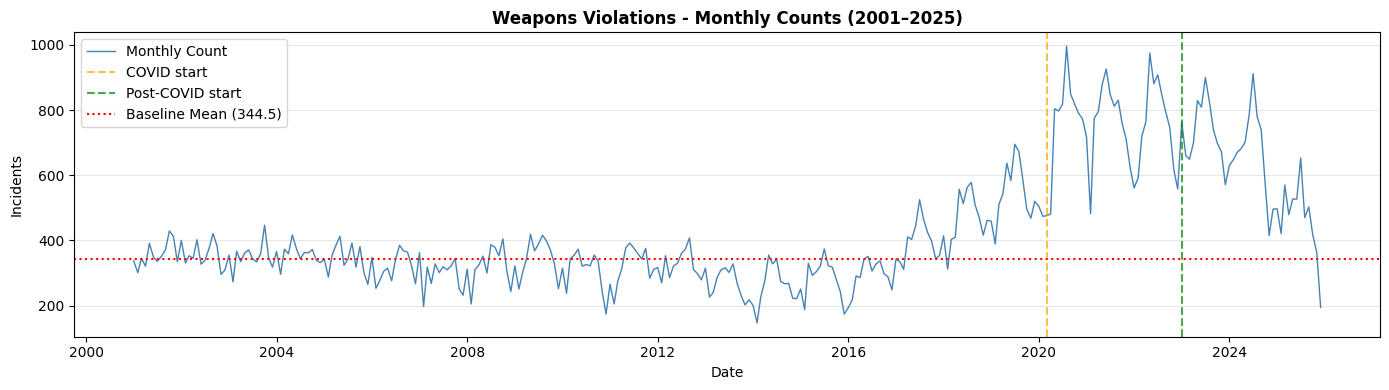

In [13]:
# Weapons Violations - Pattern 1: spiked and stayed up
plot.plot_crime_history('Weapons Violations', baseline_df, era_data_filled)

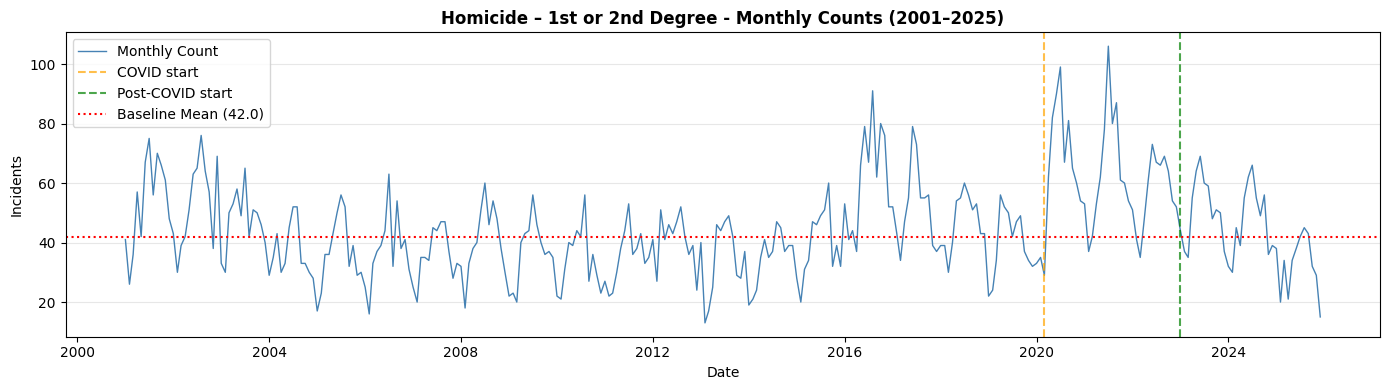

In [14]:
# Homicide - Pattern 3: spiked during COVID but recovered
plot.plot_crime_history('Homicide \u2013 1st or 2nd Degree', baseline_df, era_data_filled)

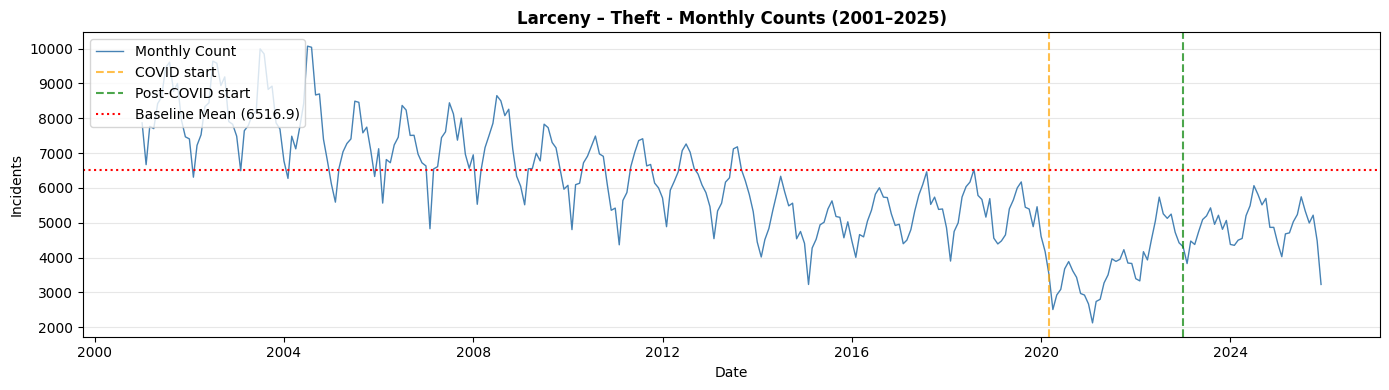

In [15]:
# Larceny - Pattern 2: dropped and stayed down
plot.plot_crime_history('Larceny \u2013 Theft', baseline_df, era_data_filled)

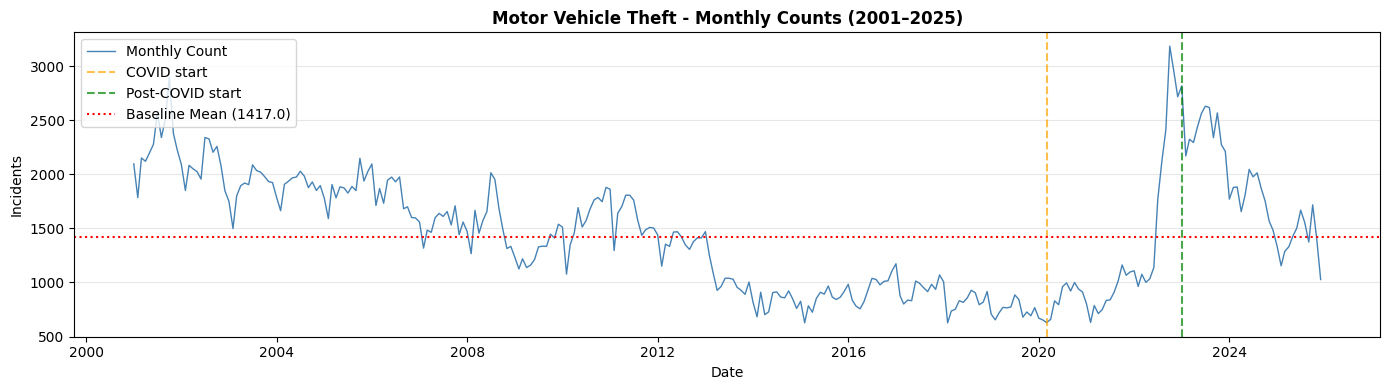

In [16]:
# Motor Vehicle Theft - caution crime: sadj_z reveals much stronger signal than z_gap
plot.plot_crime_history('Motor Vehicle Theft', baseline_df, era_data_filled)

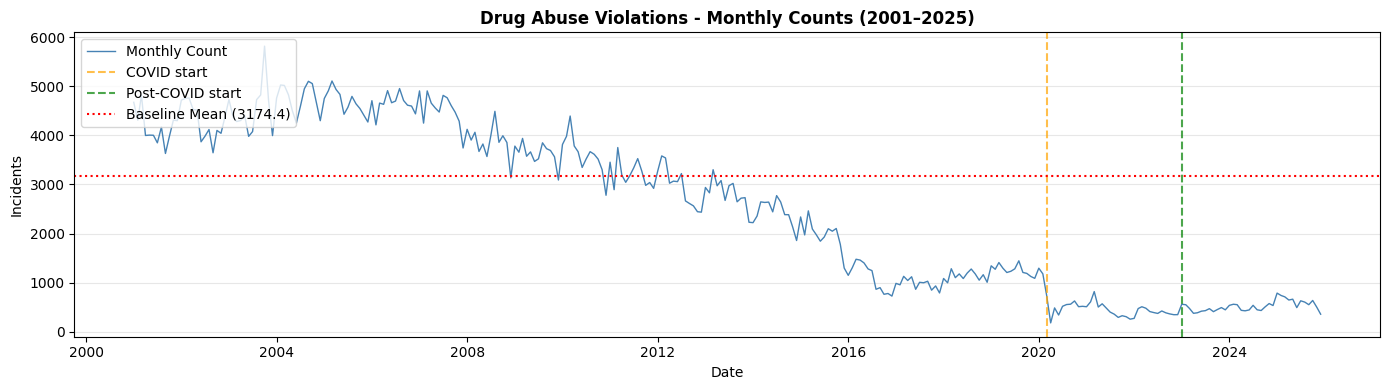

In [18]:
# Drug Abuse Violations - Pattern 4: near-elimination
plot.plot_crime_history('Drug Abuse Violations', baseline_df, era_data_filled)

## Build the Feature Matrix

A **26 × 12** feature matrix (26 crimes × 6 metrics × 2 eras), normalized and imputed, ready for both correlation and DTW clustering.

| Metric | Crimes it applies to |
|---|---|
| z_gap | All 26 |
| robust_z | 4 noisy crimes (NaN for others) |
| sadj_z | 10 caution + Liquor Laws (NaN for others) |
| r_spike | All 26 |
| pct_change | All 26 |
| presence_rate | All 26 |

> **Note on r_spike and pct_change:** These two metrics are mathematically identical after normalization - `pct_change = (r_spike − 1) × 100`. They are retained as separate columns because they serve different routing categories with non-overlapping weights: `r_spike` is the magnitude signal for reliable, use_decomp, and use_robust crimes (weight = 0.75); `pct_change` is the magnitude signal for use_presence crimes only (weight = 1.0, where r_spike = 0.0). Together, they function as a single-magnitude signal split across two routing paths, not as redundant information.
> * A `routing category` is a label that determines how a feature is processed, weighted, and interpreted within different analytical paths of a modeling pipeline.

## Assign a Weight to Each Feature

We already have a principled basis for weighting built into the pipeline - the cv_flag and routing flags - and we know which metrics are more reliable for which crimes. Weighting formalizes that knowledge into the distance calculation so the clustering algorithm respects the same statistical logic applied in Stages 2 and 3.

### Principled approach - per-crime weights

**For reliable crimes** (z_gap primary):
- `z_gap` -> 2.0 (primary - std is a reliable unit of measurement)
- `r_spike` -> 0.75 (secondary - magnitude context)
- `presence_rate` -> 0.25 (supplementary floor)
- Everything else -> 0.0 (imputed or redundant)

**For use_decomp crimes** (sadj_z primary):
- `sadj_z` -> 2.0 (primary - seasonal variance stripped, most sensitive signal)
- `z_gap` -> 1.0 (secondary - still carries directional information)
- `r_spike` -> 0.75 (secondary - magnitude context)
- `presence_rate` -> 0.25 (supplementary floor)
- Everything else -> 0.0

**For use_robust crimes** (robust_z primary):
- `robust_z` -> 2.0 (primary - resistant to outliers, honest for noisy crimes)
- `r_spike` -> 0.75 (secondary - magnitude context)
- `presence_rate` -> 0.25 (supplementary floor)
- Everything else -> 0.0

**For use_presence crimes** (Involuntary Manslaughter only):
- `presence_rate` -> 2.0 (primary - % of months with at least one incident)
- `pct_change` -> 1.0 (secondary - magnitude when it did occur)
- `z_gap` -> 0.25 (floor - unreliable but not zero)
- `robust_z` -> 0.0 (MAD = 0, undefined)
- `sadj_z` -> 0.0 (not applicable, no decomposition)
- `r_spike` -> 0.0 (pct_change already captures this)

### Final weight table

| Feature | reliable | use_decomp | use_robust | use_presence |
|---|---|---|---|---|
| z_gap | 2.0 | 1.0 | 0.0 | 0.25 |
| robust_z | 0.0 | 0.0 | 2.0 | 0.0 |
| sadj_z | 0.0 | 2.0 | 0.0 | 0.0 |
| r_spike | 0.75 | 0.75 | 0.75 | 0.0 |
| pct_change | 0.0 | 0.0 | 0.0 | 1.0 |
| presence_rate | 0.25 | 0.25 | 0.25 | 2.0 |

### Why 0.0 for unmentioned features

Every 0.0 corresponds to a metric that was either imputed (NaN filled with column median - not real data for that crime), unreliable for that crime's statistical profile, or redundant with another metric already included. Setting them to 0.0 ensures that clustering uses only metrics genuinely computed for each crime.

### Winsorizing before weighting

Extreme values are capped at $\pm$3.0 before applying weights to prevent amplification of outlier weights. Three crimes had values capped:

- **Involuntary Manslaughter** - 4 features (presence_rate, r_spike, pct_change)
- **Weapons Violations** - 4 features (z_gap, robust_z both eras)
- **Motor Vehicle Theft** - 1 feature (sadj_z_post_covid)

> **Note:** The domination check uses Euclidean distance for diagnostic purposes only. The actual clustering uses correlation and DTW distances, which are scale-invariant and pattern-based, respectively. Euclidean distance is not used in the clustering pipeline.

In [22]:
# ============================================================
# Build the Feature Matrix
# ============================================================
from scipy.spatial.distance import cdist

# Step 1: pivot metrics into wide format
# Each crime gets one row with all metrics from both eras as columns
feature_matrix = metrics.pivot(
    index='fbi_code_desc',
    columns='era',
    values=['z_gap', 'robust_z', 'sadj_z', 'r_spike', 'pct_change', 'presence_rate']
)

# Flatten multi-level column names into single strings
# e.g. ('z_gap', 'covid') -> 'z_gap_covid'
feature_matrix.columns = [f"{metric}_{era}" for metric, era in feature_matrix.columns]
feature_matrix         = feature_matrix.reset_index()

print("=" * 70)
print("STEP 1: Raw feature matrix")
print("=" * 70)
print(f"Shape : {feature_matrix.shape[0]} crimes × {feature_matrix.shape[1]-1} features")
print(f"NaNs  :")
print(feature_matrix.isnull().sum()[feature_matrix.isnull().sum() > 0].to_string())

# Step 2: separate crime labels from features
crime_labels = feature_matrix['fbi_code_desc'].values
feature_cols = [c for c in feature_matrix.columns if c != 'fbi_code_desc']
X_raw        = feature_matrix[feature_cols].copy()

# Step 3: impute NaNs
# sadj_z NaNs (16 per era): metric is not applicable for non-decomp crimes
#    impute with 0 (no seasonal deviation = neutral, not "typical decomp crime")
# robust_z NaNs (1 per era): Involuntary Manslaughter has zero MAD -> division undefined
#    impute with column median (crime is atypical; median is the best neutral proxy)
#
# Note on pct_change vs r_spike:
#   Both are linear transformations of (era_mean / baseline_mean) and are
#   mathematically identical after StandardScaler normalization.
#   They are NOT redundant in the feature matrix because the weight profiles
#   assign them to non-overlapping routing categories:
#     r_spike    -> active (weight=0.75) for reliable / use_decomp / use_robust
#     pct_change -> active (weight=1.00) for use_presence only
#   Together they act as a single magnitude signal routed by crime type. 
X_imputed = X_raw.copy()

# Columns that represent sadj_z (inapplicable for non-decomp crimes -> 0)
sadj_cols = [c for c in feature_cols if c.startswith('sadj_z')]

# Columns that represent robust_z (undefined for zero-MAD crime -> median)
robust_z_cols = [c for c in feature_cols if c.startswith('robust_z')]

# All remaining columns (no NaNs expected, but median-fill as safety net)
other_cols = [c for c in feature_cols if c not in sadj_cols + robust_z_cols]

# sadj_z -> 0 (not applicable, not missing)
for col in sadj_cols:
    n_nan = X_imputed[col].isna().sum()
    X_imputed[col] = X_imputed[col].fillna(0)
    if n_nan > 0:
        print(f"  sadj_z imputed with 0 : {col}  ({n_nan} NaNs)")

# robust_z -> column median (undefined due to zero MAD, not inapplicable)
for col in robust_z_cols:
    median_val = X_imputed[col].median()
    n_nan = X_imputed[col].isna().sum()
    X_imputed[col] = X_imputed[col].fillna(median_val)
    if n_nan > 0:
        print(f"  robust_z imputed with median ({median_val:.4f}) : {col}  ({n_nan} NaNs)")

# Other columns -> median as safety net (should be 0 NaNs)
for col in other_cols:
    median_val = X_imputed[col].median()
    X_imputed[col] = X_imputed[col].fillna(median_val)

print("\n" + "=" * 70)
print("STEP 2: After median imputation")
print("=" * 70)
print(f"\nNaNs remaining after imputation: {X_imputed.isnull().sum().sum()}")


# Step 4: z-score normalize (so pct_change doesn't dominate)
# Puts all metrics on the same scale so pct_change doesn't dominate
scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=feature_cols,
    index=crime_labels
)

print("\n" + "=" * 70)
print("STEP 3: After z-score normalization")
print("=" * 70)
print(f"Mean  ≈ 0: {(X_scaled.mean().abs() < 0.01).all()}")
print(f"Std   ≈ 1: {(X_scaled.std().round(2) == 1.02).all()}")

# Step 5: winsorize at ±3.0
# Caps extreme values before weighting to prevent weight amplification of outliers
WINSOR_CAP = 3.0
X_winsor   = X_scaled.clip(lower=-WINSOR_CAP, upper=WINSOR_CAP)

print("\n" + "=" * 70)
print("STEP 4: After winsorizing (cap = ±3.0)")
print("=" * 70)
extreme_before = (X_scaled.abs() > WINSOR_CAP).sum().sum()
extreme_after  = (X_winsor.abs() > WINSOR_CAP).sum().sum()
print(f"Values beyond ±3.0 before : {extreme_before}")
print(f"Values beyond ±3.0 after  : {extreme_after}")
print(f"\nCapped values per crime:")
capped = (X_scaled.abs() > WINSOR_CAP)
for crime in crime_labels:
    n = capped.loc[crime].sum()
    if n > 0:
        features = capped.columns[capped.loc[crime]].tolist()
        print(f"  {crime:<50} {n} feature(s): {features}")

# Step 6: define weight profiles per routing category
weight_profiles = {
    'reliable': {
        'z_gap_covid'              : 2.00,
        'z_gap_post_covid'         : 2.00,
        'robust_z_covid'           : 0.00,
        'robust_z_post_covid'      : 0.00,
        'sadj_z_covid'             : 0.00,
        'sadj_z_post_covid'        : 0.00,
        'r_spike_covid'            : 0.75,
        'r_spike_post_covid'       : 0.75,
        'pct_change_covid'         : 0.00,
        'pct_change_post_covid'    : 0.00,
        'presence_rate_covid'      : 0.25,
        'presence_rate_post_covid' : 0.25,
    },
    'use_decomp': {
        'z_gap_covid'              : 1.00,
        'z_gap_post_covid'         : 1.00,
        'robust_z_covid'           : 0.00,
        'robust_z_post_covid'      : 0.00,
        'sadj_z_covid'             : 2.00,
        'sadj_z_post_covid'        : 2.00,
        'r_spike_covid'            : 0.75,
        'r_spike_post_covid'       : 0.75,
        'pct_change_covid'         : 0.00,
        'pct_change_post_covid'    : 0.00,
        'presence_rate_covid'      : 0.25,
        'presence_rate_post_covid' : 0.25,
    },
    'use_robust': {
        'z_gap_covid'              : 0.00,
        'z_gap_post_covid'         : 0.00,
        'robust_z_covid'           : 2.00,
        'robust_z_post_covid'      : 2.00,
        'sadj_z_covid'             : 0.00,
        'sadj_z_post_covid'        : 0.00,
        'r_spike_covid'            : 0.75,
        'r_spike_post_covid'       : 0.75,
        'pct_change_covid'         : 0.00,
        'pct_change_post_covid'    : 0.00,
        'presence_rate_covid'      : 0.25,
        'presence_rate_post_covid' : 0.25,
    },
    'use_presence': {
        'z_gap_covid'              : 0.25,
        'z_gap_post_covid'         : 0.25,
        'robust_z_covid'           : 0.00,
        'robust_z_post_covid'      : 0.00,
        'sadj_z_covid'             : 0.00,
        'sadj_z_post_covid'        : 0.00,
        'r_spike_covid'            : 0.00,
        'r_spike_post_covid'       : 0.00,
        'pct_change_covid'         : 1.00,
        'pct_change_post_covid'    : 1.00,
        'presence_rate_covid'      : 2.00,
        'presence_rate_post_covid' : 2.00,
    },
}

# Step 7: assign routing category per crime
# Priority: use_presence -> use_decomp -> use_robust -> reliable
def get_routing(row):
    if row['use_presence']:
        return 'use_presence'
    elif row['use_decomp']:
        return 'use_decomp'
    elif row['use_robust']:
        return 'use_robust'
    else:
        return 'reliable'

baseline_df['routing'] = baseline_df.apply(get_routing, axis=1)

print("\n" + "=" * 70)
print("STEP 5: Routing assignment")
print("=" * 70)
print(
    baseline_df[['fbi_code_desc', 'cv_flag', 'routing']]
    .sort_values('routing')
    .to_string(index=False)
)
print(f"\nRouting breakdown: {baseline_df['routing'].value_counts().to_dict()}")

# Step 8: build per-crime weight matrix
weight_matrix = pd.DataFrame(
    index=crime_labels,
    columns=feature_cols,
    dtype=float
)
for crime in crime_labels:
    routing = baseline_df.loc[
        baseline_df['fbi_code_desc'] == crime, 'routing'
    ].values[0]
    for feature in feature_cols:
        weight_matrix.loc[crime, feature] = weight_profiles[routing][feature]

# Step 9: apply weights to winsorized matrix
# Winsorize first, then weight - prevents weight amplification of extremes
X_weighted = X_winsor * weight_matrix

# Step 10: display with short column names
display_cols = {
    'z_gap_covid'              : 'zgap_c',
    'z_gap_post_covid'         : 'zgap_p',
    'robust_z_covid'           : 'robz_c',
    'robust_z_post_covid'      : 'robz_p',
    'sadj_z_covid'             : 'sadj_c',
    'sadj_z_post_covid'        : 'sadj_p',
    'r_spike_covid'            : 'rspk_c',
    'r_spike_post_covid'       : 'rspk_p',
    'pct_change_covid'         : 'pct_c',
    'pct_change_post_covid'    : 'pct_p',
    'presence_rate_covid'      : 'pres_c',
    'presence_rate_post_covid' : 'pres_p',
}

print("\n" + "=" * 70)
print("STEP 6: Weight matrix")
print("=" * 70)
print(weight_matrix.rename(columns=display_cols).to_string())

print("\n" + "=" * 70)
print("STEP 7: Weighted feature matrix (winsorized + weighted)")
print("=" * 70)
print(X_weighted.rename(columns=display_cols).round(2).to_string())

# Step 11: domination check
# Note: Euclidean distances used here for diagnostic purposes only.
# Actual clustering uses correlation and DTW distances.
print("\n" + "=" * 70)
print("STEP 8: Domination check - Euclidean distance from outlier crimes")
print("(diagnostic only - clustering uses correlation and DTW distances)")
print("=" * 70)

print("Extreme values controlled (±3.0 cap):")
print(f"  Before winsorizing: {(X_scaled.abs() > 3.0).sum().sum()} values beyond ±3.0")
print(f"  After  winsorizing: {(X_winsor.abs() > 3.0).sum().sum()} values beyond ±3.0")

for crime, label in [
    ('Involuntary Manslaughter / Reckless Homicide', 'Involuntary Manslaughter'),
    ('Weapons Violations',                           'Weapons Violations'),
    ('Gambling',                                     'Gambling'),
]:
    dist = pd.Series(
        cdist(X_weighted.loc[[crime]], X_weighted)[0],
        index=X_weighted.index
    ).sort_values()
    print(f"\nEuclidean distance from {label} (top 5):")
    print(dist.head(6).round(2).to_string())

print("\n" + "=" * 70)
print("X_weighted ready for correlation and DTW distance computation")
print("=" * 70)
print(f"Shape : {X_weighted.shape[0]} crimes × {X_weighted.shape[1]} features")
print(f"NaNs  : {X_weighted.isnull().sum().sum()}")

STEP 1: Raw feature matrix
Shape : 26 crimes × 12 features
NaNs  :
robust_z_covid          1
robust_z_post_covid     1
sadj_z_covid           16
sadj_z_post_covid      16
  sadj_z imputed with 0 : sadj_z_covid  (16 NaNs)
  sadj_z imputed with 0 : sadj_z_post_covid  (16 NaNs)
  robust_z imputed with median (-0.9028) : robust_z_covid  (1 NaNs)
  robust_z imputed with median (-0.7959) : robust_z_post_covid  (1 NaNs)

STEP 2: After median imputation

NaNs remaining after imputation: 0

STEP 3: After z-score normalization
Mean  ≈ 0: True
Std   ≈ 1: True

STEP 4: After winsorizing (cap = ±3.0)
Values beyond ±3.0 before : 9
Values beyond ±3.0 after  : 0

Capped values per crime:
  Involuntary Manslaughter / Reckless Homicide       4 feature(s): ['r_spike_covid', 'pct_change_covid', 'presence_rate_covid', 'presence_rate_post_covid']
  Motor Vehicle Theft                                1 feature(s): ['sadj_z_post_covid']
  Weapons Violations                                 4 feature(s): ['z_gap

## Correlation and DTW Distance

### What each distance metric measures

**Correlation distance** = 1 − Pearson correlation
- Range: [0, 2] - 0 = identical direction, 1 = uncorrelated, 2 = opposite direction
- Measures how similarly two crimes' weighted feature vectors are shaped
- Scale-invariant - direction and relative magnitude matter, absolute count levels do not
- Two crimes with identical z_gap and r_spike profiles across both eras will have correlation distance ≈ 0 regardless of monthly volume
- **Answers:** Which crimes responded to COVID in statistically similar ways?

**DTW distance** (Dynamic Time Warping)
- Measures similarity of monthly count time series with elastic alignment
- Sakoe-Chiba band = 10% of series length - constrains warping to prevent pathological alignments
- Length normalized per era for fair comparison across pre (230 months), COVID (34), post (36)
- **Answers:** Which crimes had similar monthly count trajectories?

### DTW Option B - era-separated (primary)

$$total\_dtw = 0.15 \times \frac{dtw(pre_A, pre_B)}{230} + 0.55 \times \frac{dtw(covid_A, covid_B)}{34} + 0.30 \times \frac{dtw(post_A, post_B)}{36}$$

Explicitly upweights the COVID era (55%) - consistent with the era-structured analysis pipeline.

### DTW Option A - concatenated (cross-check)

All 300 months as one series. Pre-COVID dominates (77% of the series). Used only to validate that DTW-B findings are not an artifact of era weighting.

### Linkage methods tested

Three linkage methods applied to each distance matrix:
- **Single** - distance between closest pair - tends to chain
- **Complete** - distance between furthest pair - compact spherical clusters
- **Average** - mean distance between all pairs - balanced, recommended default

Ward linkage is not applicable here - requires Euclidean distance only.

### Cluster selection criteria

Two independent methods per linkage/metric combination:
- **Inconsistency coefficient** - flags where merge distances become statistically unusual relative to local merge history (threshold search: 0.7 -> 1.25)
- **Linkage gap** - finds the largest jump in the merge distance sequence (natural elbow)
- **Consensus k** - final k where both methods agree; flagged as ambiguous if they disagree

PART 1: Correlation distance matrix

Correlation distance:
  Shape          : (26, 26)
  Min            : 0.0012
  Max            : 1.9900
  Mean           : 0.9151
  Median         : 0.8947
  Std            : 0.5453
  Diagonal zeros : True
  Symmetric      : True
  NaNs           : 0


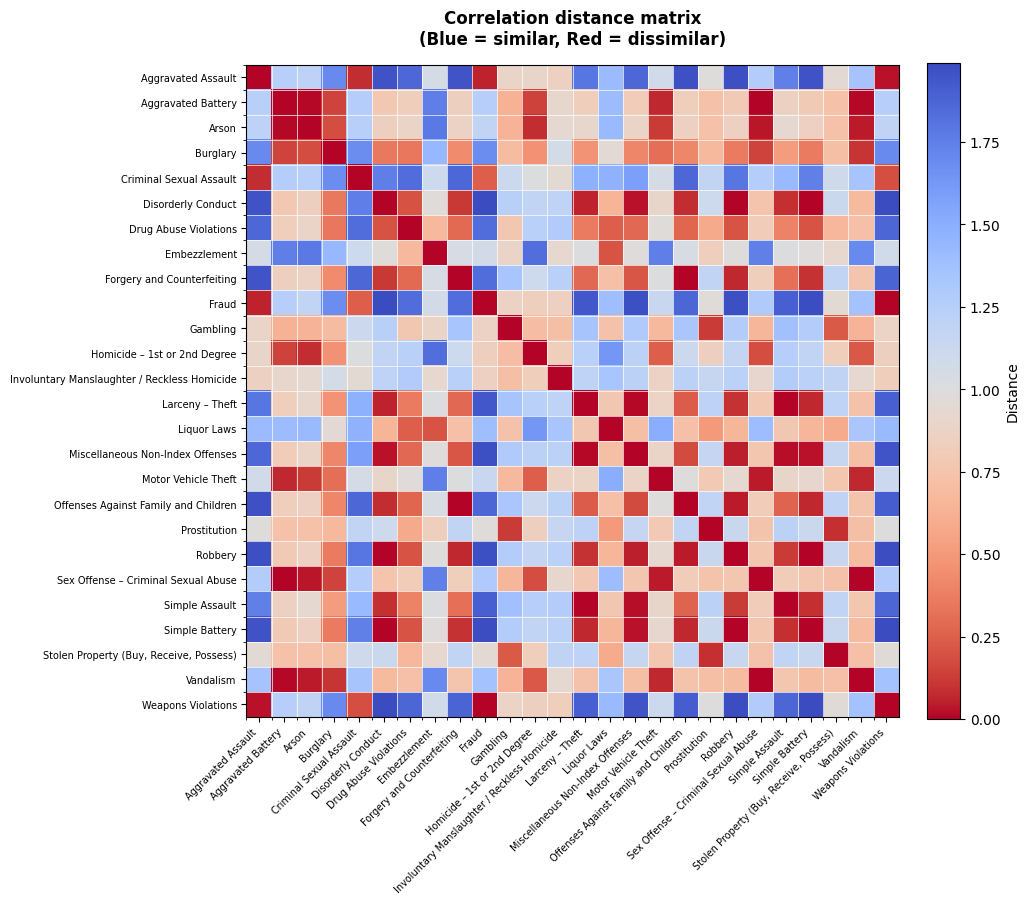


PART 2: DTW distance matrix - Option B (era-separated, primary)
Era weights : {'pre_covid': 0.15, 'covid': 0.55, 'post_covid': 0.3}
Warping pct : 0.1

DTW-B distance (era-separated):
  Shape          : (26, 26)
  Min            : 0.4434
  Max            : 676.8519
  Mean           : 166.3036
  Median         : 106.2087
  Std            : 168.6990
  Diagonal zeros : True
  Symmetric      : True
  NaNs           : 0


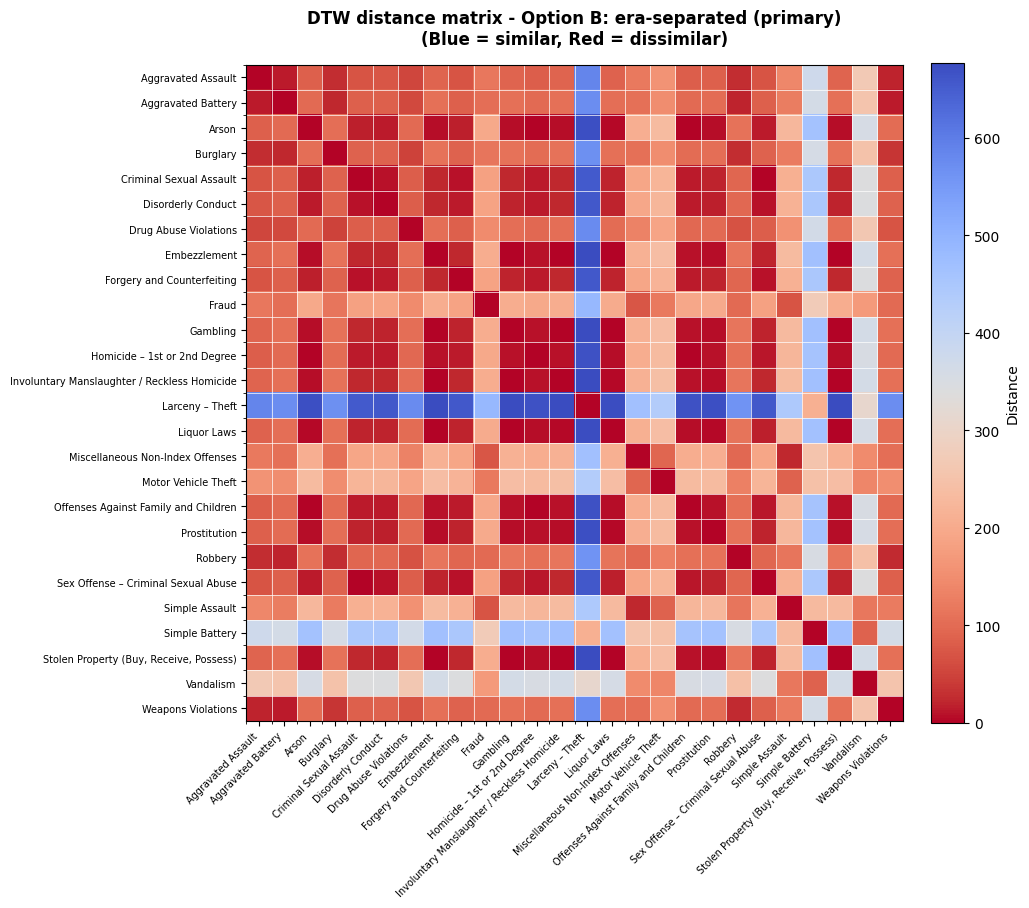


PART 3: DTW distance matrix - Option A (concatenated, cross-check)
Warping pct : 0.1

DTW-A distance (concatenated):
  Shape          : (26, 26)
  Min            : 90.2940
  Max            : 107669.1983
  Mean           : 27216.7038
  Median         : 18268.3130
  Std            : 27951.4721
  Diagonal zeros : True
  Symmetric      : True
  NaNs           : 0


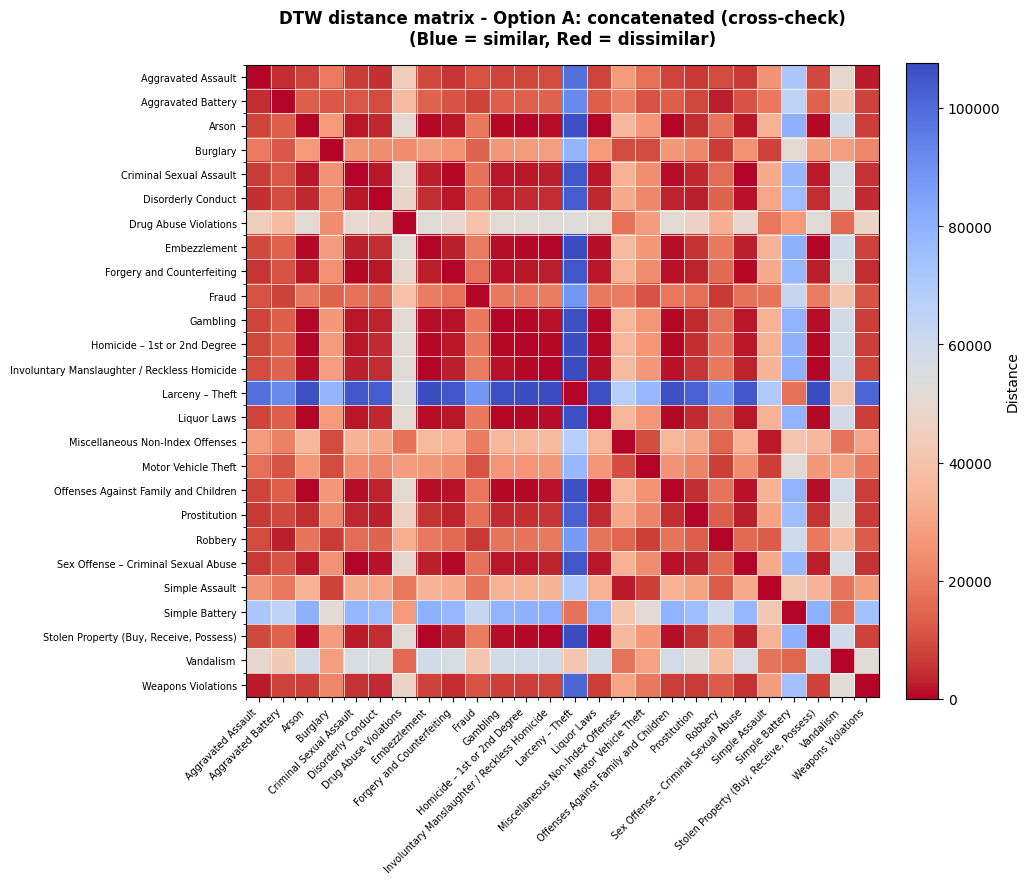


PART 4: Distance matrix comparison - Spearman rank correlation

Comparison                               rho     p-value   Sig  Interpretation
-------------------------------------------------------------------------------------
Correlation vs DTW-B                  -0.054      0.3307     N  Low agreement - captures different structure
Correlation vs DTW-A                  -0.058      0.2936     N  Low agreement - captures different structure
DTW-B vs DTW-A                         0.882      0.0000     Y  Strong agreement

PART 5: Closest neighbors - outlier crimes (top 3 per metric)

  Metric               Neighbor                                           Distance
  --------------------------------------------------------------------------------

  Involuntary Manslaughter / Reckless Homicide:
  Correlation          Gambling                                           0.7109
                       Weapons Violations                                 0.8296
                       Homicid

In [23]:
# ============================================================
# DTW Distance Computation
# ============================================================

# Helper: distance matrix stats
def distance_stats(dist_df, label):
    flat = dist_df.values[np.triu_indices(len(dist_df), k=1)]
    print(f"\n{label}:")
    print(f"  Shape          : {dist_df.shape}")
    print(f"  Min            : {flat.min():.4f}")
    print(f"  Max            : {flat.max():.4f}")
    print(f"  Mean           : {flat.mean():.4f}")
    print(f"  Median         : {np.median(flat):.4f}")
    print(f"  Std            : {flat.std():.4f}")
    print(f"  Diagonal zeros : {(np.diag(dist_df.values) == 0).all()}")
    print(f"  Symmetric      : {np.allclose(dist_df.values, dist_df.values.T)}")
    print(f"  NaNs           : {dist_df.isnull().sum().sum()}")

# Helper: distance matrix heatmap
def plot_distance_heatmap(dist_df, title):
    labels    = list(dist_df.columns)
    n         = len(labels)
    cell_size = 0.4
    fig, ax   = plt.subplots(figsize=(n * cell_size, n * cell_size))
    im        = ax.imshow(dist_df.values, cmap='coolwarm_r', aspect='auto')
    cbar      = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Distance', fontsize=10)
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    ax.grid(which='minor', color='white', linewidth=0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

# Helper: closest neighbors
def print_closest_neighbors(dist_df, crime, label, top_n=3):
    row     = dist_df.loc[crime].drop(crime)
    nearest = row.nsmallest(top_n)
    first   = True
    for neighbor, dist in nearest.items():
        met_lbl = label if first else ''
        print(f"  {met_lbl:<20} {neighbor:<50} {dist:.4f}")
        first = False

# Part 1: Correlation distance matrix
# Input  : X_weighted (26 × 12 weighted feature matrix)
# Metric : 1 - Pearson correlation
# Range  : [0, 2] - 0=identical, 1=uncorrelated, 2=opposite
print("=" * 70)
print("PART 1: Correlation distance matrix")
print("=" * 70)

corr_dist = hc.compute_correlation_distance_matrix(
    X_weighted,
    labels=list(crime_labels)
)

distance_stats(corr_dist, "Correlation distance")
plot_distance_heatmap(corr_dist, "Correlation distance matrix\n(Blue = similar, Red = dissimilar)")

# Part 2: DTW distance matrix - Option B (primary)
# Era-separated with weights: pre=0.15, covid=0.55, post=0.30
# Normalized by series length within crime_era_clustering.py
# Sakoe-Chiba band = 10% of series length per era
print("\n" + "=" * 70)
print("PART 2: DTW distance matrix - Option B (era-separated, primary)")
print("=" * 70)
print(f"Era weights : {hc.DEFAULT_ERA_WEIGHTS}")
print(f"Warping pct : {hc.DEFAULT_WARPING_PCT}")

dtw_dist_B = hc.compute_dtw_distance_matrix(
    era_data_filled = era_data_filled,
    crime_labels    = list(crime_labels),
    era_weights     = hc.DEFAULT_ERA_WEIGHTS,
    warping_pct     = hc.DEFAULT_WARPING_PCT,
    option          = 'B'
)

distance_stats(dtw_dist_B, "DTW-B distance (era-separated)")
plot_distance_heatmap(dtw_dist_B, "DTW distance matrix - Option B: era-separated (primary)\n(Blue = similar, Red = dissimilar)")

# Part 3: DTW distance matrix - Option A (cross-check)
# All 300 months concatenated as one series per crime
print("\n" + "=" * 70)
print("PART 3: DTW distance matrix - Option A (concatenated, cross-check)")
print("=" * 70)
print(f"Warping pct : {hc.DEFAULT_WARPING_PCT}")

dtw_dist_A = hc.compute_dtw_distance_matrix(
    era_data_filled = era_data_filled,
    crime_labels    = list(crime_labels),
    era_weights     = hc.DEFAULT_ERA_WEIGHTS,
    warping_pct     = hc.DEFAULT_WARPING_PCT,
    option          = 'A'
)

distance_stats(dtw_dist_A, "DTW-A distance (concatenated)")
plot_distance_heatmap(dtw_dist_A, "DTW distance matrix - Option A: concatenated (cross-check)\n(Blue = similar, Red = dissimilar)")

# Part 4: Distance matrix comparison - Spearman rank correlation
print("\n" + "=" * 70)
print("PART 4: Distance matrix comparison - Spearman rank correlation")
print("=" * 70)

idx        = np.triu_indices(len(crime_labels), k=1)
c_flat     = corr_dist.values[idx]
dtw_B_flat = dtw_dist_B.values[idx]
dtw_A_flat = dtw_dist_A.values[idx]

rho_corr_dtwB, p_corr_dtwB = spearmanr(c_flat,     dtw_B_flat)
rho_corr_dtwA, p_corr_dtwA = spearmanr(c_flat,     dtw_A_flat)
rho_dtwB_dtwA, p_dtwB_dtwA = spearmanr(dtw_B_flat, dtw_A_flat)

print(f"\n{'Comparison':<35} {'rho':>8}  {'p-value':>10}  {'Sig':>4}  Interpretation")
print("-" * 85)

for label, rho, p in [
    ('Correlation vs DTW-B', rho_corr_dtwB, p_corr_dtwB),
    ('Correlation vs DTW-A', rho_corr_dtwA, p_corr_dtwA),
    ('DTW-B vs DTW-A',       rho_dtwB_dtwA, p_dtwB_dtwA),
]:
    if rho >= 0.8:   interp = 'Strong agreement'
    elif rho >= 0.6: interp = 'Moderate agreement'
    elif rho >= 0.4: interp = 'Weak agreement'
    else:            interp = 'Low agreement - captures different structure'
    sig = 'Y' if p < 0.05 else 'N'
    print(f"{label:<35} {rho:>8.3f}  {p:>10.4f}  {sig:>4}  {interp}")

# Part 5: Closest neighbors - outlier crimes
print("\n" + "=" * 70)
print("PART 5: Closest neighbors - outlier crimes (top 3 per metric)")
print("=" * 70)

outlier_crimes = [
    'Involuntary Manslaughter / Reckless Homicide',
    'Weapons Violations',
    'Gambling',
]

print(f"\n  {'Metric':<20} {'Neighbor':<50} {'Distance':>8}")
print(f"  {'-'*80}")

for crime in outlier_crimes:
    print(f"\n  {crime}:")
    for label, dist_df in [
        ('Correlation', corr_dist),
        ('DTW-B',       dtw_dist_B),
        ('DTW-A',       dtw_dist_A),
    ]:
        print_closest_neighbors(dist_df, crime, label, top_n=3)

print("\n" + "=" * 70)
print("Distance matrices ready for Clustering")
print("=" * 70)
print(f"  corr_dist  : {corr_dist.shape}  correlation distance (feature vectors)")
print(f"  dtw_dist_B : {dtw_dist_B.shape}  DTW era-separated, primary")
print(f"  dtw_dist_A : {dtw_dist_A.shape}  DTW concatenated, cross-check")
print(f"\n  Key finding:")
print(f"  DTW-B vs DTW-A     rho = {rho_dtwB_dtwA:.3f}   - strong agreement")
print(f"  Correlation vs DTW rho ~ 0       - captures different structure")
print(f"\n  Validation:")
print(f"  Diagonal zeros : True")
print(f"  Symmetric      : True")
no_nans = not any([corr_dist.isnull().any().any(), dtw_dist_B.isnull().any().any(), dtw_dist_A.isnull().any().any()])
print(f"  No NaNs        : {no_nans}")

## Summary - Distance Computation

### Three distance matrices computed

| Matrix | Metric | Input | Purpose |
|---|---|---|---|
| `corr_dist` | Correlation | X_weighted (26×12) | Statistical response similarity |
| `dtw_dist_B` | DTW era-separated | Monthly counts, era-weighted | Count pattern similarity (primary) |
| `dtw_dist_A` | DTW concatenated | Monthly counts, 300 months | Count pattern similarity (cross-check) |

### Key findings

**Finding 1 - DTW-A and DTW-B strongly agree (ρ = 0.882, p < 0.0001)**  
The era-separated weighted approach and the concatenated approach produce nearly identical crime similarity rankings. DTW findings are robust - not an artifact of era structure or weights. The underlying count pattern similarity is stable.

**Finding 2 - Correlation and DTW fundamentally disagree (ρ ≈ 0, not significant)**  
Statistical response similarity and raw count pattern similarity are completely independent dimensions. This is valuable - not a problem:
- Crimes clustering together under **both** metrics = most robustly similar
- Crimes clustering differently = dimension-specific findings worth investigating

**Finding 3 - Count magnitude drives DTW clustering**  
Low-count crimes (Embezzlement, Stolen Property, Gambling, Involuntary Manslaughter) cluster tightly under DTW regardless of statistical profiles. High-volume crimes (Larceny ~6,500/month) are isolated. An inherent property of DTW on raw counts.

**Finding 4 - Statistical profile drives correlation clustering**  
Weapons Violations and Fraud are nearly identical under correlation (distance = 0.006) - both increased during COVID and stayed elevated. Gambling and Prostitution are nearly identical (distance = 0.12) - both near-eliminated across both eras.

### Per-era DTW hypothesis test

| Comparison | ρ | Rhythm shift | Sig |
|---|---|---|---|
| Pre vs COVID | 0.8086 | 0.1914 | ✓ |
| Pre vs Post-COVID | 0.8220 | 0.1780 | ✓ |
| COVID vs Post-COVID | 0.9749 | - | ✓ |

**Result:** Original hypothesis **NOT supported** at aggregate level.  
Temporal rhythm reorganization occurred **immediately during COVID** and persisted unchanged into post-COVID (COVID vs post-COVID ρ = 0.975).

### Refined research question

> COVID-19 simultaneously reorganized both the directional co-movement and the temporal rhythms of crime types. This reorganization persisted into the post-COVID period without further aggregate structural change; however, individual crime types may exhibit heterogeneous rhythm trajectories, with some showing delayed reorganization concentrated in the post-COVID period.

## Save to File

In [21]:
# Save all distance matrices to a single feather file
# Format: long/tidy — one row per crime pair per matrix
# Columns: matrix, crime_a, crime_b, distance
# Full matrix saved (both triangles), so reconstruction is a clean pivot()
# Path mirrors existing data file: ../Data/crime_data_covid.feather

file_list = [corr_dist, dtw_dist_B, dtw_dist_A]
names     = ['corr_dist', 'dtw_dist_B', 'dtw_dist_A']

long_frames = []
for dist_df, name in zip(file_list, names):
    # reset_index() brings crime_labels in as a column called 'fbi_code_desc'
    melted = (
        dist_df
        .reset_index()
        .rename(columns={'index': 'crime_a'})     # row crime
        .melt(
            id_vars   = 'crime_a',
            var_name  = 'crime_b',                # col crime
            value_name= 'distance'
        )
    )
    melted['matrix'] = name
    long_frames.append(melted)

dist_long = (
    pd.concat(long_frames, ignore_index=True)
    [['matrix', 'crime_a', 'crime_b', 'distance']]  # enforce column order
)

PATH = '../Data/crime_distance_matrices.feather'
feather.write_feather(dist_long, PATH)

# ── Validation ────────────────────────────────────────────────────────────────
loaded   = feather.read_feather(PATH)
expected = 3 * 26 * 26   # 3 matrices × 26×26 full grid = 2028 rows

assert len(loaded) == expected,      f"Row count wrong: {len(loaded)} ≠ {expected}"
assert loaded['distance'].isna().sum() == 0, "NaNs found in saved distances"
assert set(loaded['matrix'].unique()) == set(names), "Matrix names mismatch"

print(f"Saved   : {PATH}")
print(f"Shape   : {loaded.shape}  ({len(names)} matrices × 26 × 26)")
print(f"Columns : {list(loaded.columns)}")
print(f"Matrices: {sorted(loaded['matrix'].unique())}")
print(f"NaNs    : {loaded['distance'].isna().sum()}")
print(f"Diagonal zeros: {(loaded[loaded['crime_a'] == loaded['crime_b']]['distance'] == 0).all()}")

Saved   : ../Data/crime_distance_matrices.feather
Shape   : (2028, 4)  (3 matrices × 26 × 26)
Columns : ['matrix', 'crime_a', 'crime_b', 'distance']
Matrices: ['corr_dist', 'dtw_dist_A', 'dtw_dist_B']
NaNs    : 0
Diagonal zeros: True
